# 04 — Entrenamiento del Modelo

Entrena **MarketValueNet** (Wide & Deep) sobre los datos procesados en `data/processed/`.

**Prerequisitos:**
```bash
python -m src.features.pipeline          # genera data/processed/*.npy
# o con embeddings dummy (rápido, para probar):
python -m src.features.pipeline --dummy-text
```

**Secciones:**
1. Cargar dataset y estadísticas
2. Split temporal (train/val)
3. Arquitectura del modelo
4. Entrenamiento
5. Curvas de aprendizaje
6. Evaluación en validación
7. Guardar modelo

In [7]:
import sys
import json
import subprocess
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.model.dataset import PolymarketDataset, create_train_val_test_dataloaders
from src.model.splits import build_dataset_split
from src.model.architecture import MarketValueNet
from src.model.evaluate import evaluate_model
from src.model.metrics import compute_binary_classification_metrics
from src.model.calibration import ProbabilityCalibrator

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

ROOT = Path('..').resolve()
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
TRAINING_CFG = cfg['training']
MODEL_CFG = cfg['model']
PROCESSED = ROOT / cfg['data']['processed_dir']
MODEL_DIR = ROOT / TRAINING_CFG['save_dir']

RUN_TRAINING = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

required = ['numerical_features.npy', 'labels.npy', 'category_ids.npy', 'text_embeddings.npy']
missing = [f for f in required if not (PROCESSED / f).exists()]
assert not missing, (
    f"Faltan archivos en data/processed/: {missing}\n"
    "Correr primero: python -m src.features.pipeline"
)
print('Datos procesados disponibles:')
for f in required + ['end_dates.npy', 'pipeline/scaler.pkl']:
    exists = (PROCESSED / f).exists()
    print(f"  {'✓' if exists else '✗'} {f}")
print(f'\nCheckpoint esperado: {MODEL_DIR}')


Datos procesados disponibles:
  ✓ numerical_features.npy
  ✓ labels.npy
  ✓ category_ids.npy
  ✓ text_embeddings.npy
  ✓ end_dates.npy
  ✓ pipeline/scaler.pkl

Checkpoint esperado: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/models/market_value_baseline


## 1. Cargar dataset y estadísticas

In [8]:
dataset = PolymarketDataset.from_numpy_dir(str(PROCESSED))

n = len(dataset)
n_pos = int(dataset.labels.sum().item())
n_neg = n - n_pos

run_config_path = MODEL_DIR / 'run_config.json'
saved_run_config = json.loads(run_config_path.read_text()) if run_config_path.exists() else None
active_split_cfg = (saved_run_config or {}).get('split', {})

print(f"Dataset: {n:,} mercados")
print(f"  Positivos (Buy):    {n_pos:,} ({100*n_pos/n:.1f}%)")
print(f"  Negativos (No Buy): {n_neg:,} ({100*n_neg/n:.1f}%)")
print(f"  Features numéricas: {dataset.numerical.shape[1]}")
print(f"  Text embed dim:     {dataset.text_emb.shape[1]}")
print(f"  Timestamps:         {'sí' if dataset.timestamps is not None else 'no'}")

if saved_run_config:
    summary = {
        'split_strategy': active_split_cfg.get('strategy'),
        'val_split': active_split_cfg.get('val_split'),
        'test_split': active_split_cfg.get('test_split'),
        'train_size': active_split_cfg.get('train_size'),
        'val_size': active_split_cfg.get('val_size'),
        'test_size': active_split_cfg.get('test_size'),
        'promoted_from': saved_run_config.get('save_dir'),
    }
    print('\nArtefacto guardado detectado:')
    print(json.dumps(summary, indent=2))
else:
    print('\nNo existe run_config.json todavía; el notebook usará el split del config actual.')


Dataset: 39,545 mercados
  Positivos (Buy):    12,357 (31.2%)
  Negativos (No Buy): 27,188 (68.8%)
  Features numéricas: 25
  Text embed dim:     384
  Timestamps:         sí

Artefacto guardado detectado:
{
  "split_strategy": "temporal_grouped",
  "val_split": 0.15,
  "test_split": 0.15,
  "train_size": 27683,
  "val_size": 5935,
  "test_size": 5927,
  "promoted_from": "data/models/market_value_baseline"
}


## 2. Split reproducible train / val / test

El notebook reconstruye el split **del artefacto guardado** si existe `run_config.json`.
Eso permite inspeccionar el mismo modelo entrenado por terminal sin mezclarlo con el split actual del `config.yaml`.
Si activas `RUN_TRAINING=True`, entonces se vuelve a entrenar usando el config vigente y luego se recargan los artefactos.


{
  "strategy": "temporal_grouped",
  "seed": 42,
  "val_split": 0.15,
  "test_split": 0.15,
  "train_size": 27683,
  "val_size": 5935,
  "test_size": 5927,
  "temporal_cutoffs": {
    "val_start_timestamp": 1775743200,
    "test_start_timestamp": 1776528000
  },
  "class_balance": {
    "train_positive_rate": 0.3186432123184204,
    "val_positive_rate": 0.41752317547798157,
    "test_positive_rate": 0.17850515246391296
  }
}


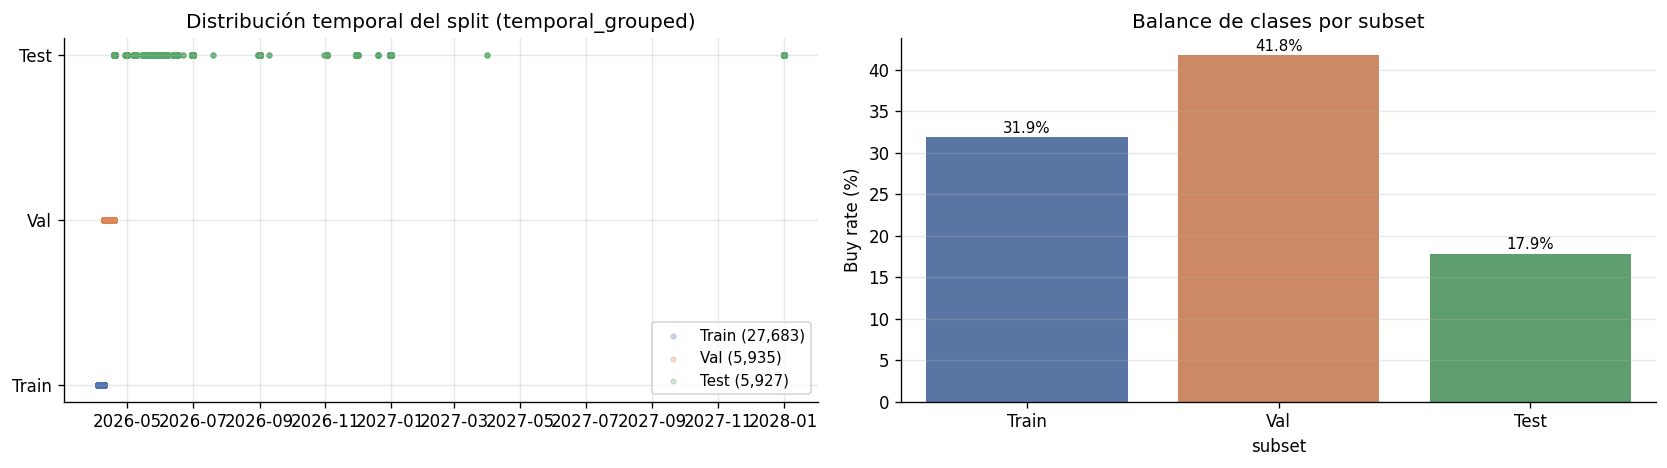

In [9]:
split_cfg = active_split_cfg or {
    'strategy': TRAINING_CFG['split_strategy'],
    'seed': TRAINING_CFG['seed'],
    'val_split': TRAINING_CFG['val_split'],
    'test_split': TRAINING_CFG['test_split'],
}

batch_size = int((saved_run_config or {}).get('batch_size', TRAINING_CFG['batch_size']))
seed = int(split_cfg.get('seed', TRAINING_CFG['seed']))
val_split = float(split_cfg.get('val_split', TRAINING_CFG['val_split']))
test_split = float(split_cfg.get('test_split', TRAINING_CFG['test_split']))
split_strategy = split_cfg.get('strategy', TRAINING_CFG['split_strategy'])

train_loader, val_loader, test_loader, split_metadata = create_train_val_test_dataloaders(
    dataset,
    batch_size=batch_size,
    val_split=val_split,
    test_split=test_split,
    split_strategy=split_strategy,
    use_weighted_sampler=TRAINING_CFG.get('use_weighted_sampler', True),
    seed=seed,
)

split = build_dataset_split(
    n_samples=len(dataset),
    labels=dataset.labels.numpy(),
    timestamps=dataset.timestamps,
    groups=dataset.groups,
    val_split=val_split,
    test_split=test_split,
    strategy=split_strategy,
    seed=seed,
)

print(json.dumps(split_metadata, indent=2))

subset_map = {
    'Train': np.array(split.train_indices),
    'Val': np.array(split.val_indices),
    'Test': np.array(split.test_indices),
}
positive_rates = {
    name: float(dataset.labels[idx].float().mean().item())
    for name, idx in subset_map.items()
    if len(idx) > 0
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
if dataset.timestamps is not None:
    timestamps = np.asarray(dataset.timestamps)
    for name, color in [('Train', PALETTE[0]), ('Val', PALETTE[1]), ('Test', PALETTE[2])]:
        idx = subset_map[name]
        if len(idx) == 0:
            continue
        dates = [dt.datetime.fromtimestamp(ts, tz=dt.timezone.utc) for ts in timestamps[idx]]
        ax.scatter(dates, [name] * len(idx), alpha=0.25, s=8, color=color, label=f'{name} ({len(idx):,})')
    ax.set_title(f'Distribución temporal del split ({split_strategy})')
    ax.legend(fontsize=9)
else:
    sizes = [len(subset_map[name]) for name in ['Train', 'Val', 'Test']]
    ax.bar(['Train', 'Val', 'Test'], sizes, color=PALETTE[:3], alpha=0.85)
    ax.set_title('Tamaños del split')

ax = axes[1]
rate_df = pd.DataFrame({
    'subset': list(positive_rates.keys()),
    'positive_rate': [100 * value for value in positive_rates.values()],
})
sns.barplot(data=rate_df, x='subset', y='positive_rate', hue='subset', palette=PALETTE[:len(rate_df)], legend=False, ax=ax)
ax.set_ylabel('Buy rate (%)')
ax.set_title('Balance de clases por subset')
for i, value in enumerate(rate_df['positive_rate']):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'train_split_overview.png', bbox_inches='tight')
plt.show()


## 3. Arquitectura del modelo

**Wide & Deep**: dos caminos que se combinan antes del head de clasificación.

- **Wide**: `numerical(23) → Linear(23, 32) → ReLU` — aprende relaciones lineales directas
- **Deep**: `[numerical + cat_emb(8) + text(384)] → BN+ReLU+Dropout × [256, 128, 64]` — aprende interacciones no lineales
- **Head**: `Linear → Sigmoid` → score ∈ (0, 1)

In [10]:
num_categories = int(dataset.categories.max().item()) + 1 if len(dataset.categories) else 1
model = MarketValueNet(
    num_numerical_features=dataset.numerical.shape[1],
    num_categories=num_categories,
    category_embed_dim=MODEL_CFG['category_embed_dim'],
    text_embed_dim=dataset.text_emb.shape[1],
    hidden_dims=MODEL_CFG['hidden_dims'],
    dropout=MODEL_CFG['dropout'],
    task=MODEL_CFG['task'],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Dispositivo:            {DEVICE}")


MarketValueNet(
  (category_embedding): Embedding(10, 8)
  (network): Sequential(
    (0): Linear(in_features=417, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros totales:     148,305
Parámetros entrenables: 148,305
Dispositivo:            cpu


## 4. Entrenamiento o carga de artefactos

Por default el notebook **no reentrena**. Solo carga `training_history.json`, `run_config.json` y `test_metrics.json`
para inspeccionar el mejor checkpoint ya promovido a `data/models/market_value_baseline/`.
Si quieres reentrenar desde el notebook, cambia `RUN_TRAINING=True` y ejecuta esta sección.


In [11]:
if RUN_TRAINING:
    cmd = [sys.executable, '-m', 'src.model.train', '--config', str(ROOT / 'config' / 'config.yaml')]
    print('Ejecutando:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)
else:
    print(f'RUN_TRAINING={RUN_TRAINING} -> usando artefactos ya guardados en {MODEL_DIR.relative_to(ROOT)}')

history_path = MODEL_DIR / 'training_history.json'
run_config_path = MODEL_DIR / 'run_config.json'
test_metrics_path = MODEL_DIR / 'test_metrics.json'
assert history_path.exists(), f'Falta {history_path}'
assert run_config_path.exists(), f'Falta {run_config_path}'
assert test_metrics_path.exists(), f'Falta {test_metrics_path}'

history = json.loads(history_path.read_text())
run_config = json.loads(run_config_path.read_text())
test_metrics = json.loads(test_metrics_path.read_text())

print('Artefactos cargados:')
print(f'  history:      {history_path.name}')
print(f'  run_config:   {run_config_path.name}')
print(f'  test_metrics: {test_metrics_path.name}')
if run_config.get('save_dir') and Path(run_config['save_dir']) != MODEL_DIR.relative_to(ROOT):
    print(f"  Nota: el checkpoint fue promovido desde `{run_config['save_dir']}` a `{MODEL_DIR.relative_to(ROOT)}`")


RUN_TRAINING=False -> usando artefactos ya guardados en data/models/market_value_baseline
Artefactos cargados:
  history:      training_history.json
  run_config:   run_config.json
  test_metrics: test_metrics.json


## 5. Curvas de aprendizaje

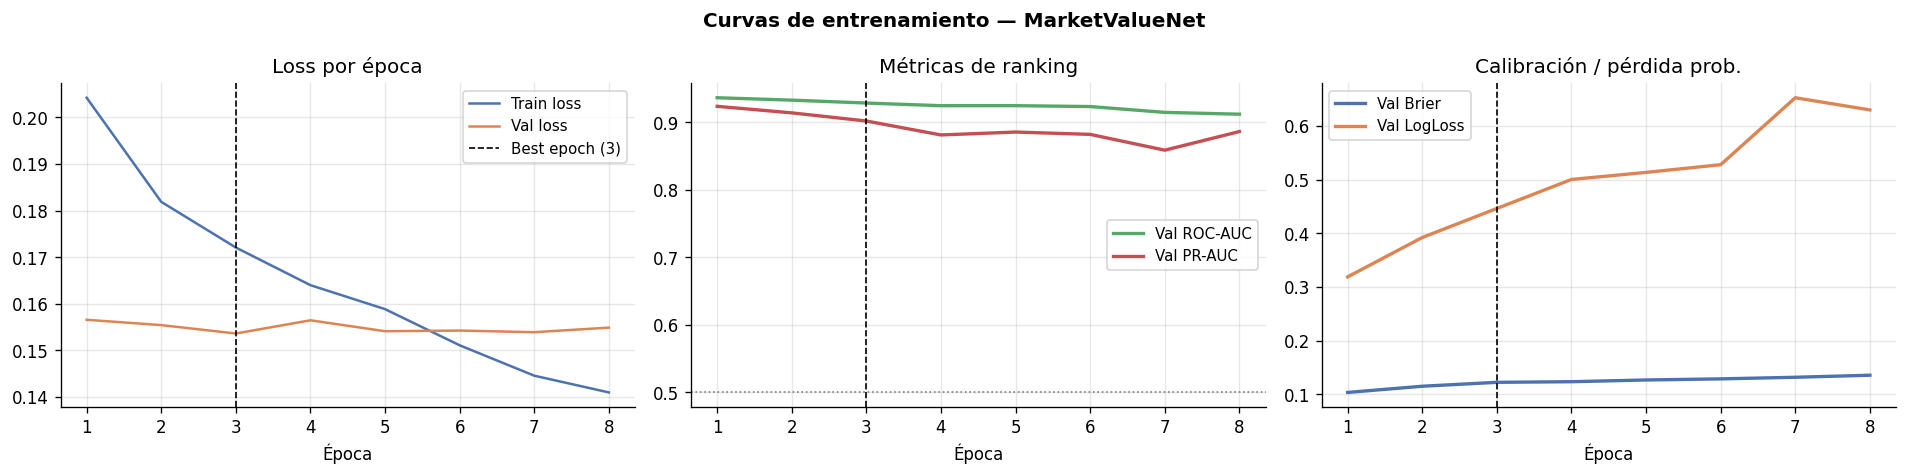

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)
best_epoch = int(history.get('best_epoch', np.argmin(history['val_loss']) + 1))

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], color=PALETTE[0], label='Train loss')
ax.plot(epochs_range, history['val_loss'], color=PALETTE[1], label='Val loss')
ax.axvline(best_epoch, color='black', linestyle='--', lw=1, label=f'Best epoch ({best_epoch})')
ax.set_title('Loss por época')
ax.set_xlabel('Época')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(epochs_range, history['val_auc'], color=PALETTE[2], linewidth=2, label='Val ROC-AUC')
ax.plot(epochs_range, history['val_pr_auc'], color=PALETTE[3], linewidth=2, label='Val PR-AUC')
ax.axvline(best_epoch, color='black', linestyle='--', lw=1)
ax.axhline(0.5, color='gray', linestyle=':', lw=1)
ax.set_title('Métricas de ranking')
ax.set_xlabel('Época')
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(epochs_range, history['val_brier'], color=PALETTE[0], linewidth=2, label='Val Brier')
ax.plot(epochs_range, history['val_log_loss'], color=PALETTE[1], linewidth=2, label='Val LogLoss')
ax.axvline(best_epoch, color='black', linestyle='--', lw=1)
ax.set_title('Calibración / pérdida prob.')
ax.set_xlabel('Época')
ax.legend(fontsize=9)

plt.suptitle('Curvas de entrenamiento — MarketValueNet', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'train_learning_curves.png', bbox_inches='tight')
plt.show()


## 6. Evaluación reproducible en validación y test

A partir del mejor checkpoint reconstruimos las métricas sobre `val` y `test` con dos cortes:
- `threshold=0.5`, que es el default más interpretable
- `threshold_tuned`, elegido en `val` para maximizar F1

Mover el threshold **no cambia** ROC-AUC ni PR-AUC; solo cambia precision, recall, F1 y accuracy.


In [13]:
best_model = MarketValueNet(
    num_numerical_features=run_config['model']['num_numerical_features'],
    num_categories=run_config['model']['num_categories'],
    category_embed_dim=run_config['model']['category_embed_dim'],
    text_embed_dim=dataset.text_emb.shape[1],
    hidden_dims=run_config['model']['hidden_dims'],
    dropout=run_config['model']['dropout'],
    task='classification',
)
best_model.load_state_dict(torch.load(MODEL_DIR / 'best_market_model.pt', map_location='cpu', weights_only=True))
calibration_dir = MODEL_DIR / 'calibration'
calibrator = ProbabilityCalibrator.load(calibration_dir) if calibration_dir.exists() else None
prediction_mode = run_config.get('prediction_mode', 'classification')
roi_cap = cfg['scoring'].get('expected_roi_cap')

val_results_default = evaluate_model(best_model, val_loader, calibrator=calibrator, prediction_mode=prediction_mode, roi_cap=roi_cap, threshold=0.5)
thresholds = np.linspace(0.05, 0.95, 37)
threshold_rows = []
for threshold in thresholds:
    metrics = compute_binary_classification_metrics(val_results_default['labels'], val_results_default['scores'], threshold=threshold)
    threshold_rows.append({'threshold': threshold, 'f1': metrics['f1'], 'precision': metrics['precision'], 'recall': metrics['recall'], 'accuracy': metrics['accuracy']})
df_thresh = pd.DataFrame(threshold_rows)
tuned_threshold = float(df_thresh.sort_values('f1', ascending=False).iloc[0]['threshold'])

val_results_tuned = evaluate_model(best_model, val_loader, calibrator=calibrator, prediction_mode=prediction_mode, roi_cap=roi_cap, threshold=tuned_threshold)
test_results_default = evaluate_model(best_model, test_loader, calibrator=calibrator, prediction_mode=prediction_mode, roi_cap=roi_cap, threshold=0.5) if test_loader is not None else None
test_results_tuned = evaluate_model(best_model, test_loader, calibrator=calibrator, prediction_mode=prediction_mode, roi_cap=roi_cap, threshold=tuned_threshold) if test_loader is not None else None

rows = []
for split_name, result in [
    ('Val @0.50', val_results_default),
    (f'Val @{tuned_threshold:.3f}', val_results_tuned),
    ('Test @0.50', test_results_default),
    (f'Test @{tuned_threshold:.3f}', test_results_tuned),
]:
    if result is None:
        continue
    rows.append({
        'split': split_name,
        'accuracy': result['accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1': result['f1'],
        'roc_auc': result['roc_auc'],
        'pr_auc': result['pr_auc'],
    })

metrics_table = pd.DataFrame(rows)
display(metrics_table.round(4))
print('Threshold tuning recalculado sobre validación:')
display(pd.DataFrame([{'threshold': tuned_threshold}]).round(4))


,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Val @0.50,0.8413,0.9021,0.6953,0.7853,0.9308,0.9049
1,Val @0.400,0.8226,0.7503,0.8620,0.8023,0.9308,0.9049
2,Test @0.50,0.9900,0.9708,0.9735,0.9722,0.9996,0.9976
3,Test @0.400,0.9789,0.8943,1.0000,0.9442,0.9996,0.9976


Threshold tuning recalculado sobre validación:


,threshold
0,0.4


/Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/.venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


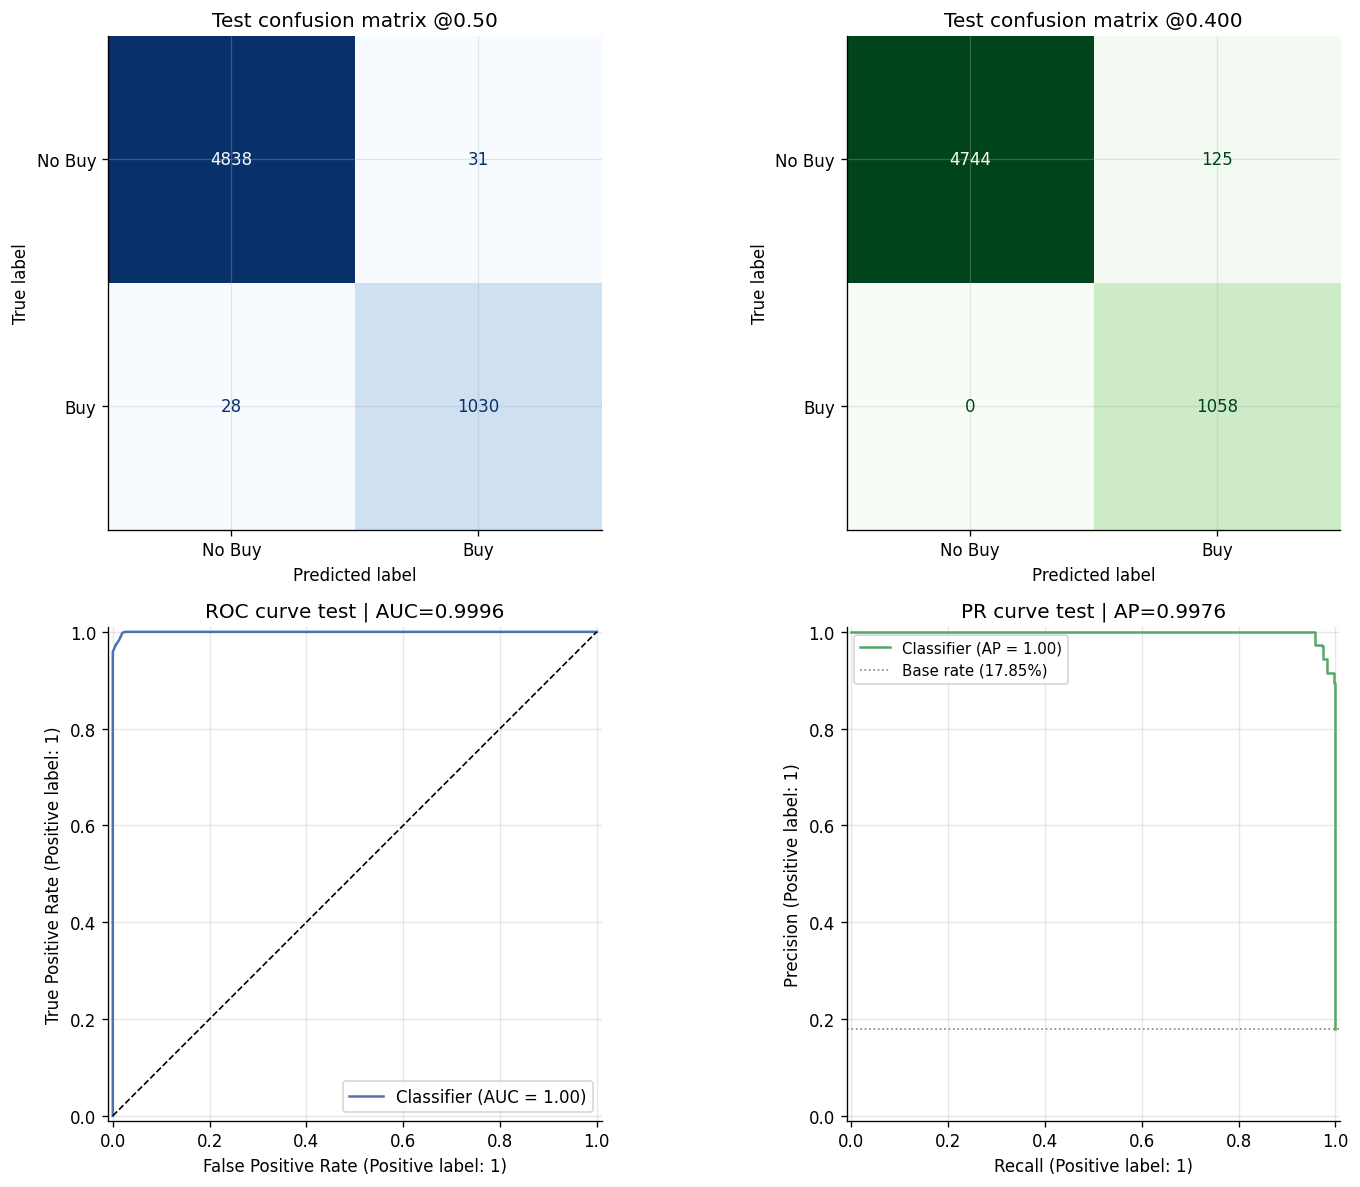

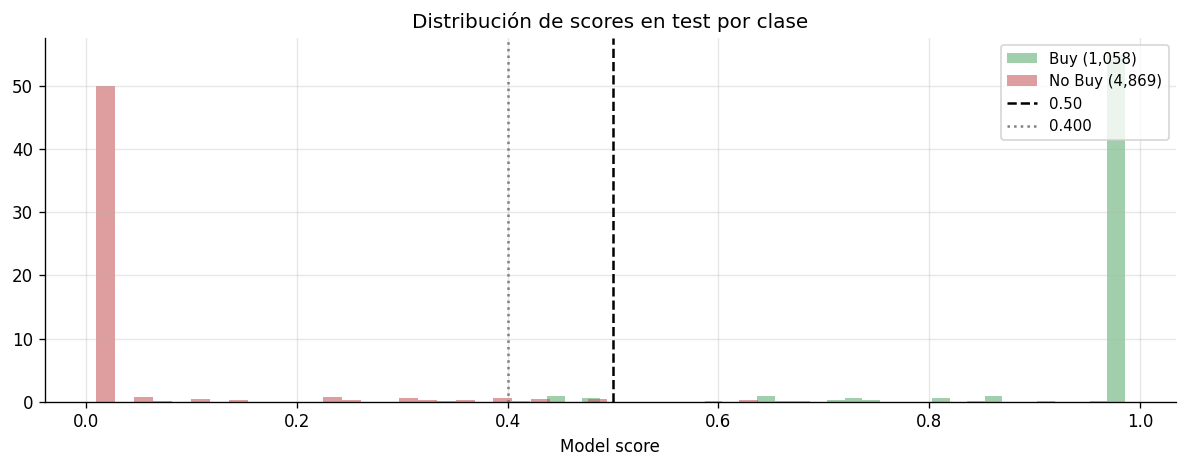

In [14]:
labels_test = test_results_default['labels']
scores_test = test_results_default['scores']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay(
    confusion_matrix=test_results_default['confusion_matrix'],
    display_labels=['No Buy', 'Buy'],
).plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Test confusion matrix @0.50')

ConfusionMatrixDisplay(
    confusion_matrix=test_results_tuned['confusion_matrix'],
    display_labels=['No Buy', 'Buy'],
).plot(ax=axes[0, 1], colorbar=False, cmap='Greens')
axes[0, 1].set_title(f'Test confusion matrix @{tuned_threshold:.3f}')

RocCurveDisplay.from_predictions(labels_test, scores_test, ax=axes[1, 0], color=PALETTE[0])
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_title(f'ROC curve test | AUC={test_results_default["roc_auc"]:.4f}')

PrecisionRecallDisplay.from_predictions(labels_test, scores_test, ax=axes[1, 1], color=PALETTE[2])
base_rate = float(np.mean(labels_test))
axes[1, 1].axhline(base_rate, color='gray', linestyle=':', lw=1, label=f'Base rate ({base_rate:.2%})')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title(f'PR curve test | AP={test_results_default["pr_auc"]:.4f}')

plt.tight_layout()
plt.savefig(FIGURES / 'train_test_evaluation.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(1, PALETTE[2], 'Buy'), (0, PALETTE[3], 'No Buy')]:
    subset = scores_test[labels_test == label]
    ax.hist(subset, bins=35, alpha=0.55, density=True, color=color, label=f'{name} ({len(subset):,})')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='0.50')
ax.axvline(tuned_threshold, color='gray', linestyle=':', lw=1.5, label=f'{tuned_threshold:.3f}')
ax.set_title('Distribución de scores en test por clase')
ax.set_xlabel('Model score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'train_test_score_distribution.png', bbox_inches='tight')
plt.show()


## 7. Threshold tuning sobre validación

El threshold se ajusta **después** de entrenar usando solo `val`.
Sirve para decidir si prefieres más `recall` (capturar más oportunidades) o más `precision` (menos falsos positivos).
`test` se usa después, una sola vez, para verificar si ese threshold generaliza.


,threshold,accuracy,precision,recall,f1,signals
14,0.400,0.8226,0.7503,0.8620,0.8023,2847
13,0.375,0.8168,0.7308,0.8886,0.8020,3013
15,0.425,0.8342,0.8005,0.8031,0.8018,2486
12,0.350,0.8066,0.7051,0.9225,0.7993,3242
17,0.475,0.8394,0.8412,0.7587,0.7978,2235
16,0.450,0.8394,0.8412,0.7587,0.7978,2235
11,0.325,0.7946,0.6823,0.9508,0.7945,3453
10,0.300,0.7810,0.6609,0.9762,0.7882,3660
9,0.275,0.7810,0.6609,0.9762,0.7882,3660
8,0.250,0.7806,0.6605,0.9766,0.7880,3664


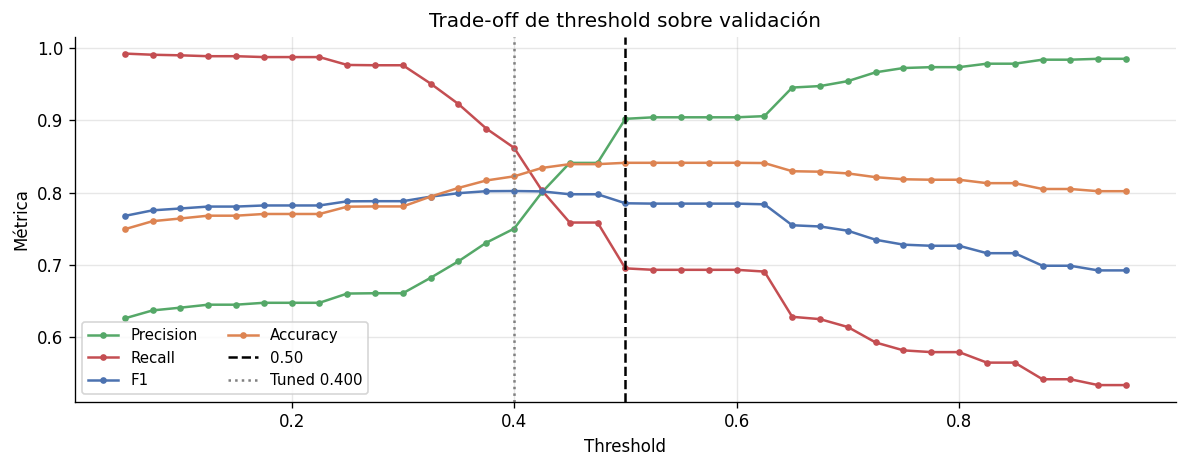

In [15]:
val_labels = val_results_default['labels']
val_scores = val_results_default['scores']
thresholds = np.linspace(0.05, 0.95, 37)
rows = []
for threshold in thresholds:
    metrics = compute_binary_classification_metrics(val_labels, val_scores, threshold=threshold)
    rows.append({
        'threshold': threshold,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'signals': int(metrics['predictions'].sum()),
    })

df_thresh = pd.DataFrame(rows)
display(df_thresh.sort_values('f1', ascending=False).head(10).round(4))

fig, ax = plt.subplots(figsize=(10, 4))
for metric, color in [('precision', PALETTE[2]), ('recall', PALETTE[3]), ('f1', PALETTE[0]), ('accuracy', PALETTE[1])]:
    ax.plot(df_thresh['threshold'], df_thresh[metric], marker='o', markersize=3, label=metric.capitalize(), color=color)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='0.50')
ax.axvline(tuned_threshold, color='gray', linestyle=':', lw=1.5, label=f'Tuned {tuned_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title('Trade-off de threshold sobre validación')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'train_threshold_analysis.png', bbox_inches='tight')
plt.show()
